In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from astropy import units as u

from prism.data import Spectrum
import prism.modeling as modeling
import prism.modeling.models as models
import prism.modeling.display

plt.rcParams['axes.xmargin'] = 0

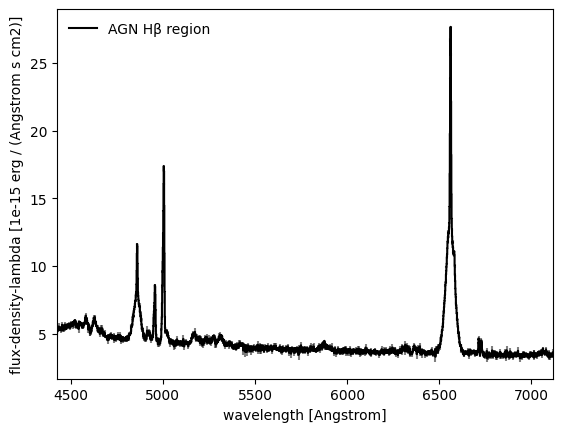

In [2]:
data_path = Path('data/agnspec.txt')   # relative to examples/

dec, ra = -25.12345, 13.12345
redshift = 0.0622

spec = Spectrum.from_txt(
    filename=str(data_path),
    redshift=redshift,
    ra=ra,
    dec=dec,
    xunit=u.AA,
    yunit=1e-15 * u.erg / (u.s * u.cm**2 * u.AA),
    name='AGN Hβ region',
)

from prism.utils.tools import get_ebv_from_map, apply_extinction_correction
# Apply Galactic extinction correction
ebv = get_ebv_from_map(ra, dec)
spec.y, spec.yerr = apply_extinction_correction(wave=spec.x, flux=spec.y, fluxerr=spec.yerr, ebv=ebv, rv=3.1)

# (Optional) Apply redshift correction to rest frame
spec.x /= (1 + spec.redshift)
spec.y *= (1 + spec.redshift)
spec.yerr *= (1 + spec.redshift)

# spec.crop(bounds=(4820.0, 4940.0))
spec.plot_spectrum()

In [3]:
from prism.modeling.io import load_params, load_model

modelfile = "results/agnmodel.fits"

# params = load_params(modelfile) # parameters dictionary
model = load_model(modelfile) # model object

/Users/pierpaolo/SciSoft/git/prism-spec/.venv/lib/python3.11/site-packages/yaml/constructor.py:100: UserWarning: Model was saved with a direct response matrix that cannot be reconstructed from a recipe.  Re-apply the response manually.
  data = constructor(self, node)


In [4]:
# # ── Attach parameter uncertainties ───────────────────────────────────────────
# # If the model was saved after covar_attach/resample_attach, uncertainties are
# # already restored and this cell is not needed.
# # Otherwise, re-fit briefly with ScipyTRF to populate .std on parameters.
# # The parameter values from the loaded model are already optimal — the re-fit
# # just computes the covariance around that solution.

# from prism.modeling.fitting.uncertainty import covar_attach

# if not any(getattr(getattr(model, pn), 'std', None) is not None
#            for pn in model.param_names):
#     fitter = fitting.ScipyTRF(calc_uncertainties=True)
#     model = fitter(model, x=spec.wave, y=spec.flux, weights=1.0 / spec.err)
#     covar_attach(model, fitter)
#     print("Uncertainties attached via ScipyTRF covariance.")

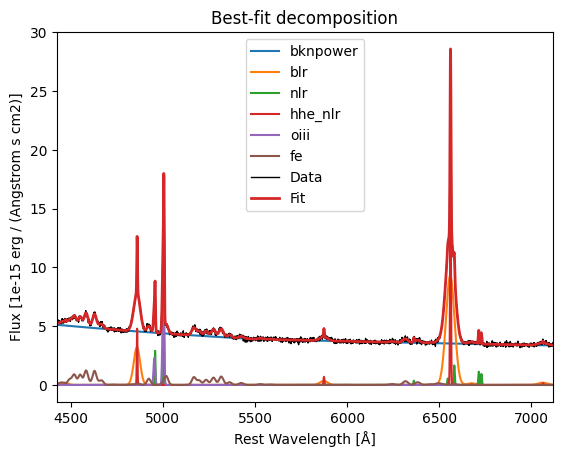

In [5]:
comps = modeling.models.get_components(model, additive=True)

plt.figure()
for name in comps.names:
    plt.plot(spec.x, comps[name](spec.x), label=name)

plt.plot(spec.x, spec.y, color='black', lw=1, label='Data')
plt.plot(spec.x, model(spec.x), color='tab:red', lw=2, label='Fit')

plt.xlabel('Rest Wavelength [Å]')
plt.ylabel(f'Flux [{spec.yunit}]')
plt.legend()
plt.title('Best-fit decomposition')
plt.show()

In [6]:
comps.names

['bknpower', 'blr', 'nlr', 'hhe_nlr', 'oiii', 'fe']

In [7]:
# Select_line collects all components contributing to the 'Hb4861' physical tag
line = modeling.select_line(model=model, selector='Hb4861')
line

SelectedLineProfile(selector='Hb4861', components=2)

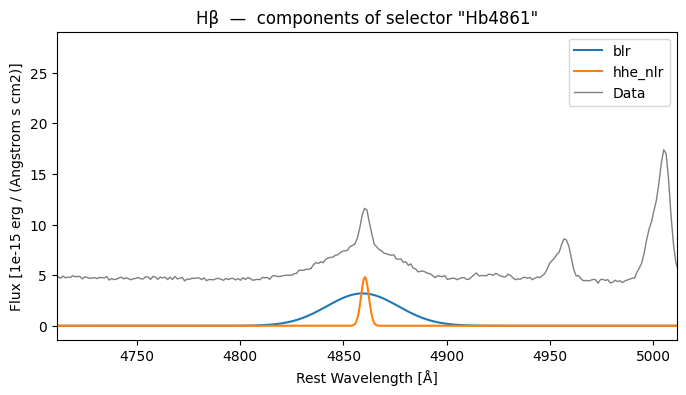

Rest position: 4861.325 Å


In [8]:
# ── Plot each contributing component separately ───────────────────────────────
# evaluate_components() returns a dict {component_name: flux_array}.
# This lets you inspect the individual substructure of the blended line.
wave_line = np.linspace(line.position-150, line.position+150, 500)

plt.figure(figsize=(8, 4))
for name, flux in line.evaluate_components(x=wave_line).items():
    plt.plot(wave_line, flux, label=name)
plt.plot(spec.x, spec.y, color='black', lw=1, alpha=0.5, label='Data')
plt.xlabel('Rest Wavelength [Å]')
plt.ylabel(f'Flux [{spec.yunit}]')
plt.title(f'Hβ  —  components of selector "{line.selector}"')
plt.xlim(wave_line[0], wave_line[-1])
plt.legend()
plt.show()

print(f"Rest position: {line.position:.3f} Å")

In [9]:
# ── Measurement without uncertainties ────────────────────────────────────────
# hb.measure() integrates the combined profile over an inferred wavelength window.
# Each attribute is a Metric; .value holds the nominal result.
m = line.measure()

print(f"Flux        : {m.flux.value:.4g}")
print(f"FWHM        : {m.fwhm.value:.4g} Å")
print(f"Centroid    : {m.moment1.value:.4g} Å")
print(f"Moment2     : {m.moment2.value:.4g} Å²")
print(f"Skewness    : {m.skewness.value:.4g}")
print(f"Asymmetry   : {m.asymmetry.value:.4g}")
print(f"Bisect span : {m.bisector_span.value:.4g} Å")

Flux        : 160.8
FWHM        : 6.967 Å
Centroid    : 4859 Å
Moment2     : 254.9 Å²
Skewness    : -0.03036
Asymmetry   : -0.00468
Bisect span : 1.146 Å


In [10]:
# ── Measurement with uncertainties via parameter sampling ─────────────────────
# hb.sample() draws N parameter sets from the covariance attached by covar_attach,
# re-integrates the profile for each draw, and returns percentile-based bounds.
# The returned LineResult has the same attributes as hb.measure(), now with .std/.lolim/.uplim.
#
# method=  'auto' (default) | 'covariance' | 'limits' | 'std'
# distribution=  'auto' (default) | 'uniform' | 'gaussian'
# Parameter draws are automatically clipped to parameter bounds.
# Limits use boundary-aware extract_limits (NaN when truncated at a bound).
# NOTE: for fluxes width and peak amplitude are typically negatively correlated,
# when amplitude goes up, fwhm tends to go down, and vice versa.
# Using method='covariance' might correctly give smaller uncertainties than method='std'
s = line.sample(n_samples=1000, method='covariance', random_state=7)

# Each Metric prints as  "value ± std  [lolim, uplim]"
print(f"Flux    : {s.flux}")
print(f"FWHM    : {s.fwhm}")
print(f"Moment2 : {s.moment2}")

Flux    : 160.8 ± 0.1616  [160.6, 160.9]
FWHM    : 6.967 ± 0.0214 Angstrom  [6.945, 6.988]
Moment2 : 254.9 ± 0.2978 Angstrom2  [254.6, 255.2]


In [11]:
model.covariance

array([[ 1.93297973e-06, -3.31170878e-03,  2.00090252e-06, ...,
        -2.70165583e-07,  5.96582142e-04,  6.65933407e-04],
       [-3.31170878e-03,  6.93230979e+00, -5.60355453e-03, ...,
         3.74316685e-04, -1.37840903e+00, -2.03529000e+00],
       [ 2.00090252e-06, -5.60355453e-03,  1.02001580e-05, ...,
         5.59756881e-08,  8.30072255e-04,  1.29860693e-03],
       ...,
       [-2.70165583e-07,  3.74316685e-04,  5.59756881e-08, ...,
         4.50642251e-06, -5.60114597e-04, -3.71033820e-04],
       [ 5.96582142e-04, -1.37840903e+00,  8.30072255e-04, ...,
        -5.60114597e-04,  4.97667413e+00,  7.59965202e-01],
       [ 6.65933407e-04, -2.03529000e+00,  1.29860693e-03, ...,
        -3.71033820e-04,  7.59965202e-01,  8.22709325e+00]],
      shape=(46, 46))

In [12]:
flux = s.flux
print(f"Total Hβ flux = {flux.value:.3f} ± {flux.std:.3f}  "
      f"(68% CI: [{flux.lolim:.3f}, {flux.uplim:.3f}])")

Total Hβ flux = 160.779 ± 0.162  (68% CI: [160.624, 160.944])


In [13]:
# ── All 16 metrics in one table ───────────────────────────────────────────────
# Columns: value (nominal integral), std, lolim, uplim — all from the same sample draws.
# Metrics: flux, peak_value, peak_position, fwhm, hw_blue, hw_red, asymmetry,
#          moment1 (centroid), moment2 (variance), sigma, skewness, kurtosis,
#          fw10m, fw20m, fw80m (widths at 10/20/80% of peak), bisector_span.
metrics = s.to_frame()
metrics

,value,std,lolim,uplim,unit
flux,160.779011,0.161591,160.62414,160.944003,NaN
peak_value,8.006556,0.029352,7.979347,8.038504,NaN
peak_position,4860.349204,0.0,4860.349204,4860.349204,Angstrom
fwhm,6.96691,0.021397,6.944531,6.987676,Angstrom
hw_blue,3.499759,0.011371,3.487727,3.510736,Angstrom
hw_red,3.467151,0.010035,3.456464,3.476907,Angstrom
asymmetry,-0.00468,0.000199,-0.004879,-0.004479,NaN
moment1,4859.385114,0.006474,4859.378142,4859.391276,Angstrom
moment2,254.94856,0.297814,254.645411,255.228738,Angstrom2
sigma,15.967109,0.009326,15.957613,15.97588,Angstrom


In [14]:
# Access specific entry (pandas.DataFrame)
metrics.loc['flux', 'value']

160.77901145887148